# 21. Deep Promotion Time Cure Model (Deep-PTCM) for Competing Risks

**Reference:** Medina-Olivares, V., Lessmann, S. & Klein, N. (2024). "The Deep Promotion Time Cure Model." *IEEE Trans. Neural Netw. Learn. Syst.*, 35(12), 18848-18858.

## Methodology

The **Promotion Time Cure Model (PTCM)** assumes each borrower $i$ has $K_i \sim \text{Poisson}(\theta(\mathbf{x}_i))$ unobserved latent risk factors. Borrowers with $K_i = 0$ are **cured** -- they never experience the event. The cure fraction is $\pi(\mathbf{x}) = \exp(-\theta(\mathbf{x}))$.

The **Deep-PTCM** replaces the traditional linear predictor $\log\theta = \mathbf{w}^\top\mathbf{x} + b$ with a deep neural network, optionally decomposed via **orthogonalization** into interpretable linear effects plus a nonlinear residual.

### Competing Risks Extension

We extend the single-event PTCM to competing risks (prepayment + default) via independent latent causes:

$$S(t; \mathbf{x}) = \prod_k \exp\bigl(-\theta_k(\mathbf{x})\, F_k(t)\bigr)$$

where $F_k$ is a piecewise-exponential baseline CDF for cause $k$, and $\theta_k$ is parameterized by a shared DNN with cause-specific heads.

### Key Advantages
- **Cure fractions**: Explicitly models the probability that a borrower will *never* prepay or default
- **Flexible nonlinearity**: DNN captures complex covariate interactions
- **Interpretability**: Orthogonalization separates linear from nonlinear effects

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch

sys.path.insert(0, str(Path.cwd().parent))

from src.competing_risks.deep_ptcm import (
    CompetingRisksDeepPTCM,
    fit_deep_ptcm_competing_risks,
    STATIC_FEATURES,
    TRAIN_FOLDS,
    VAL_FOLDS,
    TEST_FOLD,
    get_device,
)
from src.competing_risks.evaluation import (
    time_dependent_concordance_index,
    brier_score_competing_risks,
    auc_cure,
    integrated_brier_score,
    EVAL_TIMES,
)

from sklearn.preprocessing import StandardScaler

print(f"PyTorch {torch.__version__}")
print(f"Device: {get_device()}")

PyTorch 2.3.1
Device: mps


## Configuration

In [2]:
# --- Paths ---
DATA_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
FIGURES_DIR = Path('../figures/21_deep_ptcm')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# --- Features ---
FEATURE_COLS = ['int_rate', 'log_upb', 'fico_score', 'dti_r', 'ltv_r']

# --- Hyperparameters (aligned with Medina-Olivares et al. 2024) ---
PTCM_PARAMS = dict(
    num_intervals=15,
    shared_layers=[512, 512],
    head_layers=[],
    dropout=0.2,
    batch_norm=False,
    orthogonalize=False,
    lr=0.01,
    weight_decay=0.0,
    lr_decay_rate=0.75,
    lr_decay_steps=100,
    batch_size=512,
    epochs=200,
    patience=20,
    verbose=True,
    random_state=42,
)

# --- Event mapping ---
EVENT_NAMES = {0: 'Censored', 1: 'Prepay', 2: 'Default'}

print("Feature columns:", FEATURE_COLS)
print("PTCM hyperparameters:")
for k, v in PTCM_PARAMS.items():
    print(f"  {k}: {v}")

Feature columns: ['int_rate', 'log_upb', 'fico_score', 'dti_r', 'ltv_r']
PTCM hyperparameters:
  num_intervals: 15
  shared_layers: [512, 512]
  head_layers: []
  dropout: 0.2
  batch_norm: False
  orthogonalize: False
  lr: 0.01
  weight_decay: 0.0
  lr_decay_rate: 0.75
  lr_decay_steps: 100
  batch_size: 512
  epochs: 200
  patience: 20
  verbose: True
  random_state: 42


## Data Loading

In [3]:
df = pd.read_parquet(DATA_DIR / 'blumenstock_dataset2.parquet')

# Derive log_upb
df['log_upb'] = np.log(df['orig_upb'].clip(lower=1).astype(float))

print(f"Loaded {len(df):,} loans")
print(f"Vintages: {df['vintage_year'].min()} - {df['vintage_year'].max()}")
print(f"Duration range: {df['duration'].min()} - {df['duration'].max()} months")
print(f"\nEvent distribution:")
for code, name in EVENT_NAMES.items():
    n = (df['event_code'] == code).sum()
    print(f"  {name} (k={code}): {n:,} ({100*n/len(df):.1f}%)")
print(f"\nFolds: {sorted(df['fold'].unique())}")
print(f"Missing values in features:")
for c in FEATURE_COLS:
    print(f"  {c}: {df[c].isna().sum()}")

Loaded 110,000 loans
Vintages: 2010 - 2025
Duration range: 0 - 184 months

Event distribution:
  Censored (k=0): 47,386 (43.1%)
  Prepay (k=1): 61,514 (55.9%)
  Default (k=2): 1,100 (1.0%)

Folds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Missing values in features:
  int_rate: 0
  log_upb: 0
  fico_score: 0
  dti_r: 0
  ltv_r: 0


## Train / Validation / Test Split

In [4]:
# Drop rows with missing features
df_clean = df.dropna(subset=FEATURE_COLS).copy()
print(f"After dropping NaN: {len(df_clean):,} loans (dropped {len(df) - len(df_clean):,})")

# Split by folds (matching DeepHit / Sadhwani notebooks)
train_df = df_clean[df_clean['fold'].isin(TRAIN_FOLDS)].copy()
val_df = df_clean[df_clean['fold'].isin(VAL_FOLDS)].copy()
test_df = df_clean[df_clean['fold'] == TEST_FOLD].copy()

print(f"\nTraining set (folds {TRAIN_FOLDS}): {len(train_df):,} loans")
print(f"Validation set (fold {VAL_FOLDS}): {len(val_df):,} loans")
print(f"Test set (fold {TEST_FOLD}): {len(test_df):,} loans")

for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{name} event distribution:")
    for code, ename in EVENT_NAMES.items():
        n = (split_df['event_code'] == code).sum()
        print(f"  {ename}: {n:,}")

After dropping NaN: 110,000 loans (dropped 0)

Training set (folds [0, 1, 2, 3, 4, 5, 6, 7, 8]): 90,000 loans
Validation set (fold [9]): 10,000 loans
Test set (fold 10): 10,000 loans

Train event distribution:
  Censored: 38,772
  Prepay: 50,328
  Default: 900

Val event distribution:
  Censored: 4,324
  Prepay: 5,576
  Default: 100

Test event distribution:
  Censored: 4,290
  Prepay: 5,610
  Default: 100


## Model Training (Deep-PTCM)

In [5]:
model = fit_deep_ptcm_competing_risks(
    df=train_df,
    feature_cols=FEATURE_COLS,
    duration_col='duration',
    event_col='event_code',
    event_types=[1, 2],
    val_df=val_df,
    **PTCM_PARAMS,
)

print(f"\nTraining complete.")
print(f"  Epochs run: {len(model.history_['train_loss'])}")
print(f"  Best val loss: {min(model.history_['val_loss']):.4f}")
print(f"  Breakpoints: {model.breakpoints_}")

  Epoch   0 | train 9.1976 | val 8.1843 | lr 9.9e-03 | wait 0/20


  Epoch   1 | train 7.5005 | val 6.9320 | lr 9.9e-03 | wait 0/20


  Epoch   2 | train 6.5260 | val 6.1788 | lr 9.8e-03 | wait 0/20


  Epoch   3 | train 5.9025 | val 5.6629 | lr 9.7e-03 | wait 0/20


  Epoch   4 | train 5.4603 | val 5.2830 | lr 9.6e-03 | wait 0/20


...

  Epoch 195 | train 3.1722 | val 3.1822 | lr 4.0e-03 | wait 0/20


  Epoch 196 | train 3.1726 | val 3.1820 | lr 4.0e-03 | wait 0/20


  Epoch 197 | train 3.1722 | val 3.1818 | lr 4.0e-03 | wait 0/20


  Epoch 198 | train 3.1719 | val 3.1814 | lr 4.0e-03 | wait 0/20


  Epoch 199 | train 3.1709 | val 3.1813 | lr 4.0e-03 | wait 0/20

Training complete.
  Epochs run: 200
  Best val loss: 3.1813
  Breakpoints: [  0.        12.333333  24.666666  37.        49.333332  61.666668
  74.        86.333336  98.666664 111.       123.333336 135.66667
 148.       160.33333  172.66667  185.      ]


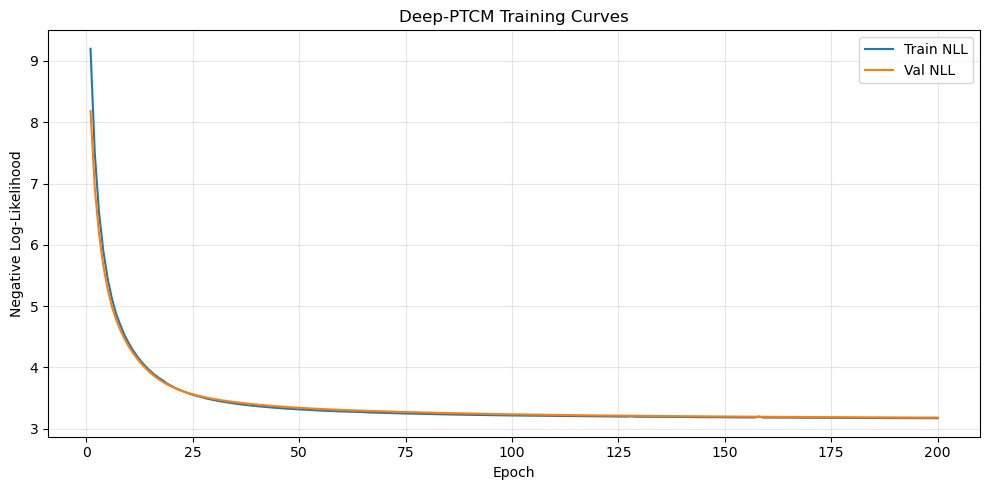

In [6]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 5))
epochs = range(1, len(model.history_['train_loss']) + 1)
ax.plot(epochs, model.history_['train_loss'], label='Train NLL')
ax.plot(epochs, model.history_['val_loss'], label='Val NLL')
ax.set_xlabel('Epoch')
ax.set_ylabel('Negative Log-Likelihood')
ax.set_title('Deep-PTCM Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cure Fraction Analysis

The cure fraction $\pi_k(\mathbf{x}) = \exp(-\theta_k(\mathbf{x}))$ gives the probability that borrower $\mathbf{x}$ will **never** experience event $k$.

In [7]:
# Compute cure fractions on test set
cure = model.predict_cure_fraction(test_df[FEATURE_COLS])

print("Cure fraction statistics (test set):")
for name, values in cure.items():
    print(f"\n  {name}:")
    print(f"    Mean:   {values.mean():.4f}")
    print(f"    Median: {np.median(values):.4f}")
    print(f"    Min:    {values.min():.4f}")
    print(f"    Max:    {values.max():.4f}")

# Compare to observed rates
n_test = len(test_df)
obs_cens = (test_df['event_code'] == 0).sum() / n_test
obs_prepay = (test_df['event_code'] == 1).sum() / n_test
obs_default = (test_df['event_code'] == 2).sum() / n_test
print(f"\nObserved rates: censored={obs_cens:.3f}, prepay={obs_prepay:.3f}, default={obs_default:.3f}")

Cure fraction statistics (test set):

  prepay:
    Mean:   0.1920
    Median: 0.1806
    Min:    0.0101
    Max:    0.9282

  default:
    Mean:   0.9884
    Median: 0.9930
    Min:    0.8208
    Max:    1.0000

  overall:
    Mean:   0.1899
    Median: 0.1783
    Min:    0.0101
    Max:    0.9282

Observed rates: censored=0.429, prepay=0.561, default=0.010


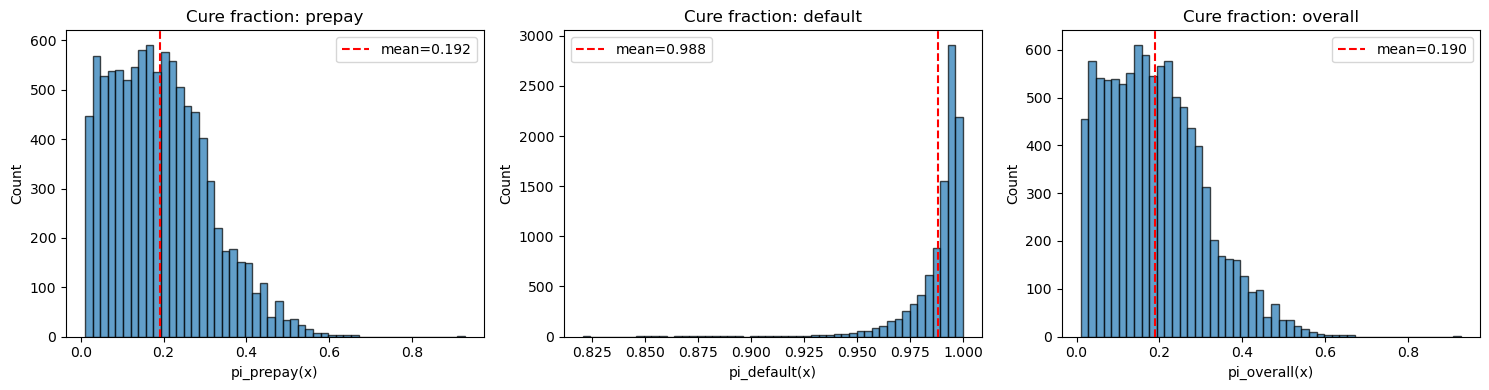

In [8]:
# Cure fraction distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, values) in zip(axes, cure.items()):
    ax.hist(values, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'Cure fraction: {name}')
    ax.set_xlabel(f'pi_{name}(x)')
    ax.set_ylabel('Count')
    ax.axvline(values.mean(), color='red', linestyle='--', label=f'mean={values.mean():.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cure_fraction_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# AUC_cure: ability to discriminate cured vs uncured borrowers
# Three flavours:
#   overall  : pi_overall = P(never any event); uncured = experienced any event
#   prepay   : pi_prepay  = P(never prepay);    uncured = prepaid;
#                                               cured includes default events
#                                               (competing-event convention)
#   default  : pi_default = P(never default);   uncured = defaulted;
#                                               cured includes prepay events
ec_arr = test_df['event_code'].values
du_arr = test_df['duration'].values

auc_overall = auc_cure(ec_arr, du_arr, cure['overall'], min_followup=120)
auc_prepay  = auc_cure(ec_arr, du_arr, cure['prepay'],  min_followup=120, event_of_interest=1)
auc_default = auc_cure(ec_arr, du_arr, cure['default'], min_followup=120, event_of_interest=2)

print(f"AUC_cure (min_followup=120):")
print(f"  overall: {auc_overall:.4f}")
print(f"  prepay : {auc_prepay :.4f}")
print(f"  default: {auc_default:.4f}")

# Sensitivity to the follow-up threshold
print(f"\nFollow-up threshold sweep:")
print(f"  {'mf':>3s} | {'overall':>8s} | {'prepay':>8s} | {'default':>8s} | n_long_cens")
for mf in [60, 84, 120, 150]:
    auc_o = auc_cure(ec_arr, du_arr, cure['overall'], min_followup=mf)
    auc_p = auc_cure(ec_arr, du_arr, cure['prepay'],  min_followup=mf, event_of_interest=1)
    auc_d = auc_cure(ec_arr, du_arr, cure['default'], min_followup=mf, event_of_interest=2)
    n_long_cens = ((ec_arr == 0) & (du_arr >= mf)).sum()
    print(f"  {mf:>3d} | {auc_o:>8.4f} | {auc_p:>8.4f} | {auc_d:>8.4f} | {n_long_cens:,}")

## Model Evaluation

### Time-Dependent Concordance Index

In [10]:
# Predict risk scores (CIF at evaluation times) for both events
test_durations = test_df['duration'].values
test_events = test_df['event_code'].values
X_test = test_df[FEATURE_COLS]

results_rows = []
for event_code, event_name in [(1, 'Prepay'), (2, 'Default')]:
    print(f"\n=== {event_name} (k={event_code}) ===")
    for t in EVAL_TIMES:
        risk_scores = model.predict_risk(X_test, event=event_code, time=t)
        c_idx, n_conc, n_comp = time_dependent_concordance_index(
            test_durations, test_events, risk_scores, t, event_code
        )
        bs = brier_score_competing_risks(
            test_durations, test_events,
            model.predict_cumulative_incidence(X_test, event=event_code, times=np.array([t]))[:, 0],
            t, event_code
        )
        print(f"  t={t:3d}: C-index={c_idx:.4f}  BS={bs:.4f}  (n_comparable={n_comp:,})")
        results_rows.append({
            'Event': event_name, 'Horizon': t,
            'C-index': c_idx, 'Brier Score': bs,
        })

results_df = pd.DataFrame(results_rows)

# Add means
for event_name in ['Prepay', 'Default']:
    mask = results_df['Event'] == event_name
    mean_c = results_df.loc[mask, 'C-index'].mean()
    mean_bs = results_df.loc[mask, 'Brier Score'].mean()
    results_rows.append({'Event': event_name, 'Horizon': 'Mean', 'C-index': mean_c, 'Brier Score': mean_bs})

results_df = pd.DataFrame(results_rows)
print("\n=== Summary ===")
print(results_df.to_string(index=False))


=== Prepay (k=1) ===


  t= 24: C-index=0.6535  BS=0.1500  (n_comparable=13,088,079)


  t= 48: C-index=0.6765  BS=0.2148  (n_comparable=14,053,014)


  t= 72: C-index=0.6449  BS=0.2423  (n_comparable=10,375,300)

=== Default (k=2) ===
  t= 24: C-index=0.7153  BS=0.0038  (n_comparable=247,197)
  t= 48: C-index=0.7245  BS=0.0066  (n_comparable=264,924)
  t= 72: C-index=0.7001  BS=0.0083  (n_comparable=193,200)

=== Summary ===
  Event Horizon  C-index  Brier Score
 Prepay      24 0.653470     0.150023
 Prepay      48 0.676494     0.214779
 Prepay      72 0.644895     0.242316
Default      24 0.715344     0.003774
Default      48 0.724464     0.006592
Default      72 0.700140     0.008311
 Prepay    Mean 0.658287     0.202373
Default    Mean 0.713316     0.006226


### Integrated Brier Score

In [11]:
# Integrated Brier Score over [1, 72] months
ibs_grid = np.arange(1, 73, dtype='float32')

for event_code, event_name in [(1, 'Prepay'), (2, 'Default')]:
    cif_at_grid = model.predict_cumulative_incidence(
        X_test, event=event_code, times=ibs_grid
    )
    ibs = integrated_brier_score(
        test_durations, test_events,
        cif_at_grid, ibs_grid,
        event_of_interest=event_code,
    )
    print(f"IBS ({event_name}, t=1..72): {ibs:.6f}")

IBS (Prepay, t=1..72): 0.166290
IBS (Default, t=1..72): 0.004972


## Survival and CIF Curves

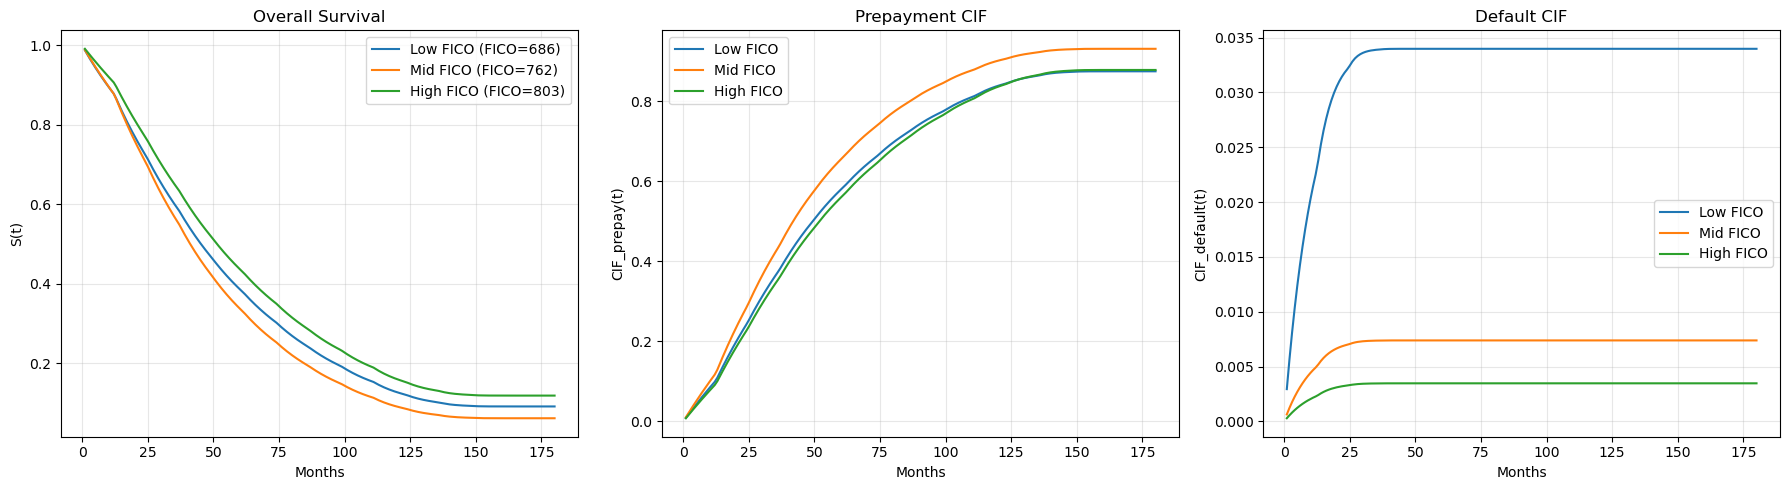

In [12]:
# Select example loans: one low-risk, one medium, one high-risk (by FICO)
test_sorted = test_df.sort_values('fico_score')
idx_low = test_sorted.index[len(test_sorted) // 10]       # low FICO
idx_med = test_sorted.index[len(test_sorted) // 2]        # median FICO
idx_high = test_sorted.index[9 * len(test_sorted) // 10]  # high FICO
example_indices = [idx_low, idx_med, idx_high]
example_labels = ['Low FICO', 'Mid FICO', 'High FICO']

times_grid = np.linspace(1, 180, 180).astype('float32')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Overall survival
ax = axes[0]
for idx, label in zip(example_indices, example_labels):
    X_ex = test_df.loc[[idx], FEATURE_COLS]
    surv = model.predict_survival(X_ex, times=times_grid)
    fico = test_df.loc[idx, 'fico_score']
    ax.plot(times_grid, surv[0], label=f'{label} (FICO={fico:.0f})')
ax.set_xlabel('Months')
ax.set_ylabel('S(t)')
ax.set_title('Overall Survival')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Prepayment CIF
ax = axes[1]
for idx, label in zip(example_indices, example_labels):
    X_ex = test_df.loc[[idx], FEATURE_COLS]
    cif = model.predict_cumulative_incidence(X_ex, event=1, times=times_grid)
    ax.plot(times_grid, cif[0], label=label)
ax.set_xlabel('Months')
ax.set_ylabel('CIF_prepay(t)')
ax.set_title('Prepayment CIF')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Default CIF
ax = axes[2]
for idx, label in zip(example_indices, example_labels):
    X_ex = test_df.loc[[idx], FEATURE_COLS]
    cif = model.predict_cumulative_incidence(X_ex, event=2, times=times_grid)
    ax.plot(times_grid, cif[0], label=label)
ax.set_xlabel('Months')
ax.set_ylabel('CIF_default(t)')
ax.set_title('Default CIF')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'survival_cif_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Verify CIF consistency: S(t) + CIF_1(t) + CIF_2(t) should equal 1
X_check = test_df[FEATURE_COLS].head(100)
t_check = np.array([24, 48, 72, 120, 180], dtype='float32')
surv = model.predict_survival(X_check, times=t_check)
cif1 = model.predict_cumulative_incidence(X_check, event=1, times=t_check)
cif2 = model.predict_cumulative_incidence(X_check, event=2, times=t_check)

total = surv + cif1 + cif2
print("S(t) + CIF_1(t) + CIF_2(t) should be close to 1.0:")
for i, t in enumerate(t_check):
    print(f"  t={t:5.0f}: mean={total[:, i].mean():.6f}, max_deviation={np.abs(total[:, i] - 1.0).max():.6f}")

S(t) + CIF_1(t) + CIF_2(t) should be close to 1.0:
  t=   24: mean=0.998687, max_deviation=0.002306
  t=   48: mean=0.999279, max_deviation=0.001486
  t=   72: mean=0.998850, max_deviation=0.001921
  t=  120: mean=0.998695, max_deviation=0.001907
  t=  180: mean=0.999170, max_deviation=0.001748


## Orthogonalized Model (Deep-PTCM-Ort)

The orthogonalized variant decomposes the predictor as $g_k(\mathbf{x}) = \mathbf{w}_k^\top\mathbf{x} + b_k + \text{ort}_k(\mathbf{x})$, where the nonlinear component is constrained to be orthogonal to the linear span of $\mathbf{X}$. This yields interpretable linear coefficients while retaining full DNN flexibility.

In [14]:
# Train orthogonalized variant
PTCM_ORT_PARAMS = {**PTCM_PARAMS, 'orthogonalize': True}

model_ort = fit_deep_ptcm_competing_risks(
    df=train_df,
    feature_cols=FEATURE_COLS,
    duration_col='duration',
    event_col='event_code',
    event_types=[1, 2],
    val_df=val_df,
    **PTCM_ORT_PARAMS,
)

print(f"\nOrthogonalized model training complete.")
print(f"  Epochs run: {len(model_ort.history_['train_loss'])}")
print(f"  Best val loss: {min(model_ort.history_['val_loss']):.4f}")

  Epoch   0 | train 17.1956 | val 16.5291 | lr 9.9e-03 | wait 0/20


  Epoch   1 | train 14.8424 | val 14.6016 | lr 9.9e-03 | wait 0/20


  Epoch   2 | train 13.8247 | val 13.4694 | lr 9.8e-03 | wait 0/20


  Epoch   3 | train 13.3338 | val 12.7387 | lr 9.7e-03 | wait 0/20


  Epoch   4 | train 12.4792 | val 12.2234 | lr 9.6e-03 | wait 0/20


...

  Epoch  30 | train 6.4743 | val 5.1008 | lr 8.1e-03 | wait 5/20


  Epoch  36 | train 5.5607 | val 3.4284 | lr 7.8e-03 | wait 0/20


  Epoch  40 | train 4.2669 | val 3.3923 | lr 7.6e-03 | wait 0/20


  Epoch  50 | train 4.1335 | val 4.6340 | lr 7.2e-03 | wait 10/20


  Epoch  60 | train 4.1956 | val 4.5138 | lr 6.9e-03 | wait 20/20
  Early stopping at epoch 60

Orthogonalized model training complete.
  Epochs run: 61
  Best val loss: 3.3923


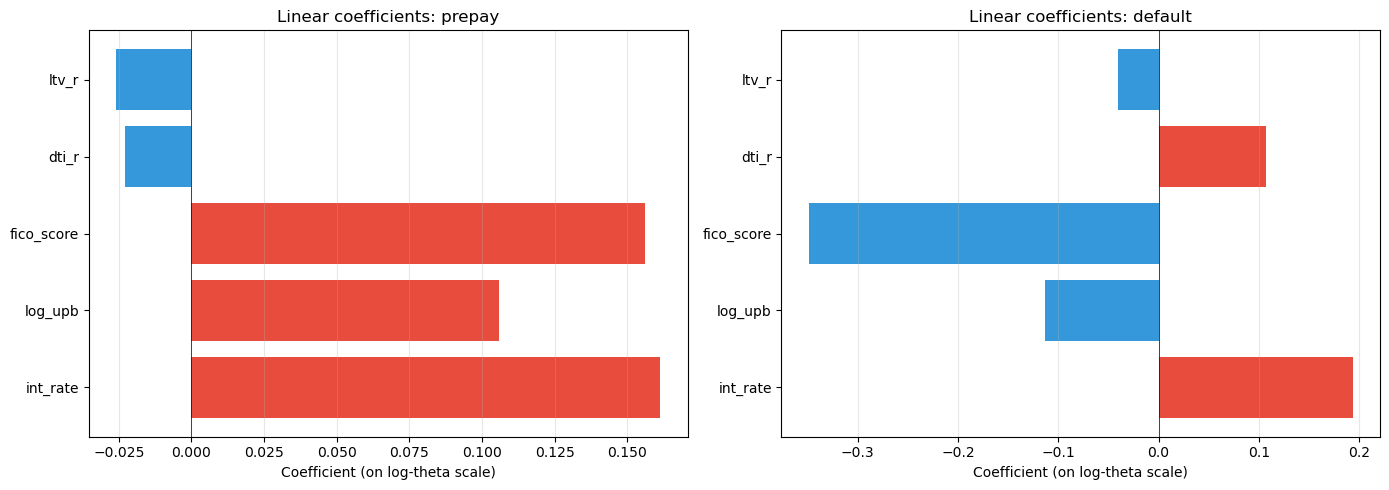


prepay:
    feature  coefficient
   int_rate     0.161289
    log_upb     0.105649
 fico_score     0.156029
      dti_r    -0.022845
      ltv_r    -0.025911
(intercept)    -0.127432

default:
    feature  coefficient
   int_rate     0.193495
    log_upb    -0.113183
 fico_score    -0.348711
      dti_r     0.107266
      ltv_r    -0.040492
(intercept)    -0.662138


In [15]:
# Extract and display linear coefficients
coefs = model_ort.get_linear_coefficients()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (event_name, coef_df) in zip(axes, coefs.items()):
    # Exclude intercept for the bar plot
    plot_df = coef_df[coef_df['feature'] != '(intercept)'].copy()
    colors = ['#e74c3c' if c > 0 else '#3498db' for c in plot_df['coefficient']]
    ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
    ax.set_title(f'Linear coefficients: {event_name}')
    ax.set_xlabel('Coefficient (on log-theta scale)')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'orthogonalized_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# Print coefficients
for event_name, coef_df in coefs.items():
    print(f"\n{event_name}:")
    print(coef_df.to_string(index=False))

In [16]:
# Compare Deep-PTCM vs Deep-PTCM-Ort on test set
print("=== Deep-PTCM vs Deep-PTCM-Ort ===\n")
comparison_rows = []

for model_obj, model_name in [(model, 'Deep-PTCM'), (model_ort, 'Deep-PTCM-Ort')]:
    for event_code, event_name in [(1, 'Prepay'), (2, 'Default')]:
        for t in EVAL_TIMES:
            risk = model_obj.predict_risk(X_test, event=event_code, time=t)
            c_idx, _, _ = time_dependent_concordance_index(
                test_durations, test_events, risk, t, event_code
            )
            comparison_rows.append({
                'Model': model_name, 'Event': event_name,
                'Horizon': t, 'C-index': c_idx,
            })

comp_df = pd.DataFrame(comparison_rows)
pivot = comp_df.pivot_table(
    index=['Event', 'Horizon'], columns='Model', values='C-index'
)
print(pivot.round(4).to_string())

=== Deep-PTCM vs Deep-PTCM-Ort ===



Model            Deep-PTCM  Deep-PTCM-Ort
Event   Horizon                          
Default 24          0.7153         0.6825
        48          0.7245         0.6950
        72          0.7001         0.6491
Prepay  24          0.6535         0.6504
        48          0.6765         0.6766
        72          0.6449         0.6445


## Ablation: Deeper Cause-Specific Heads

The paper uses a single linear output per cause (since it models only default). With competing risks, prepayment and default have distinct risk profiles that may require more cause-specific capacity. We test adding a hidden layer of 32 units to each head (`head_layers=[32]`) and compare all four variants.

In [17]:
# Train Deep-PTCM with deeper heads (head_layers=[32])
PTCM_HEAD32_PARAMS = {**PTCM_PARAMS, 'head_layers': [32]}

model_head32 = fit_deep_ptcm_competing_risks(
    df=train_df,
    feature_cols=FEATURE_COLS,
    duration_col='duration',
    event_col='event_code',
    event_types=[1, 2],
    val_df=val_df,
    **PTCM_HEAD32_PARAMS,
)

print(f"\nDeep-PTCM (head=[32]) training complete.")
print(f"  Epochs run: {len(model_head32.history_['train_loss'])}")
print(f"  Best val loss: {min(model_head32.history_['val_loss']):.4f}")

# Train Deep-PTCM-Ort with deeper heads
PTCM_ORT_HEAD32_PARAMS = {**PTCM_PARAMS, 'head_layers': [32], 'orthogonalize': True}

model_ort_head32 = fit_deep_ptcm_competing_risks(
    df=train_df,
    feature_cols=FEATURE_COLS,
    duration_col='duration',
    event_col='event_code',
    event_types=[1, 2],
    val_df=val_df,
    **PTCM_ORT_HEAD32_PARAMS,
)

print(f"\nDeep-PTCM-Ort (head=[32]) training complete.")
print(f"  Epochs run: {len(model_ort_head32.history_['train_loss'])}")
print(f"  Best val loss: {min(model_ort_head32.history_['val_loss']):.4f}")

  Epoch   0 | train 9.4375 | val 8.2925 | lr 9.9e-03 | wait 0/20


  Epoch   1 | train 7.5813 | val 6.9849 | lr 9.9e-03 | wait 0/20


  Epoch   2 | train 6.5756 | val 6.2206 | lr 9.8e-03 | wait 0/20


  Epoch   3 | train 5.9439 | val 5.7010 | lr 9.7e-03 | wait 0/20


  Epoch   4 | train 5.4987 | val 5.3193 | lr 9.6e-03 | wait 0/20


...

  Epoch 195 | train 3.6953 | val 3.1790 | lr 4.0e-03 | wait 0/20


  Epoch 196 | train 3.1732 | val 3.1780 | lr 4.0e-03 | wait 0/20


  Epoch 197 | train 3.6053 | val 3.1777 | lr 4.0e-03 | wait 0/20


  Epoch 198 | train 3.2509 | val 3.1773 | lr 4.0e-03 | wait 0/20


  Epoch 199 | train 3.1683 | val 3.1772 | lr 4.0e-03 | wait 0/20

Deep-PTCM-Ort (head=[32]) training complete.
  Epochs run: 200
  Best val loss: 3.1772


In [ ]:
# Compare all four variants
print("=== 4-Model Comparison: head_layers=[] vs head_layers=[32] ===\n")

all_models = [
    (model,           'Deep-PTCM'),
    (model_ort,       'Deep-PTCM-Ort'),
    (model_head32,    'Deep-PTCM (head=[32])'),
    (model_ort_head32,'Deep-PTCM-Ort (head=[32])'),
]

all_rows = []
for model_obj, model_name in all_models:
    for event_code, event_name in [(1, 'Prepay'), (2, 'Default')]:
        for t in EVAL_TIMES:
            risk = model_obj.predict_risk(X_test, event=event_code, time=t)
            c_idx, _, _ = time_dependent_concordance_index(
                test_durations, test_events, risk, t, event_code
            )
            cif_t = model_obj.predict_cumulative_incidence(
                X_test, event=event_code, times=np.array([t])
            )[:, 0]
            bs = brier_score_competing_risks(
                test_durations, test_events, cif_t, t, event_code
            )
            all_rows.append({
                'Model': model_name, 'Event': event_name,
                'Horizon': t, 'C-index': c_idx, 'Brier Score': bs,
            })

all_comp_df = pd.DataFrame(all_rows)

# C-index comparison
print("--- C-index ---")
c_pivot = all_comp_df.pivot_table(
    index=['Event', 'Horizon'], columns='Model', values='C-index'
)
print(c_pivot.round(4).to_string())

# Brier score comparison
print("\n--- Brier Score ---")
bs_pivot = all_comp_df.pivot_table(
    index=['Event', 'Horizon'], columns='Model', values='Brier Score'
)
print(bs_pivot.round(6).to_string())

# Mean metrics per model
print("\n--- Mean C-index by Model and Event ---")
mean_c = all_comp_df.groupby(['Model', 'Event'])['C-index'].mean().unstack()
print(mean_c.round(4).to_string())

# AUC_cure: overall + cause-specific
print("\n--- AUC_cure (min_followup=120) ---")
print(f"  {'Model':<32s} | {'overall':>8s} | {'prepay':>8s} | {'default':>8s}")
for model_obj, model_name in all_models:
    cure_pred = model_obj.predict_cure_fraction(X_test)
    auc_o = auc_cure(test_events, test_durations, cure_pred['overall'], min_followup=120)
    auc_p = auc_cure(test_events, test_durations, cure_pred['prepay'],  min_followup=120, event_of_interest=1)
    auc_d = auc_cure(test_events, test_durations, cure_pred['default'], min_followup=120, event_of_interest=2)
    print(f"  {model_name:<32s} | {auc_o:>8.4f} | {auc_p:>8.4f} | {auc_d:>8.4f}")

## Feature Importance (Permutation)


Prepay:
   feature  importance
  int_rate    0.080644
   log_upb    0.071930
     dti_r    0.021649
     ltv_r    0.004692
fico_score    0.003104



Default:
   feature  importance
fico_score    0.130036
     ltv_r    0.033674
  int_rate    0.012753
     dti_r    0.007773
   log_upb    0.000386


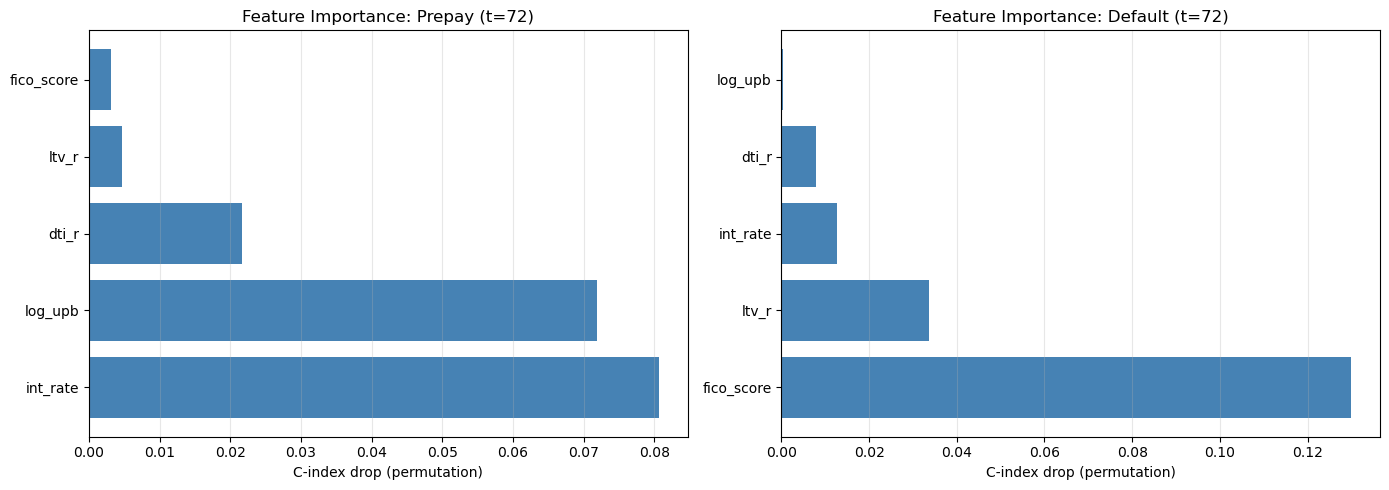

In [19]:
# Permutation importance: shuffle each feature and measure C-index drop
def permutation_importance(model_obj, X_df, durations, events, feature_cols,
                           event_code, eval_time=72, n_repeats=5, seed=42):
    """Compute permutation importance for each feature."""
    rng = np.random.RandomState(seed)
    
    # Baseline C-index
    base_risk = model_obj.predict_risk(X_df, event=event_code, time=eval_time)
    base_c, _, _ = time_dependent_concordance_index(
        durations, events, base_risk, eval_time, event_code
    )
    
    importances = {}
    for feat in feature_cols:
        drops = []
        for _ in range(n_repeats):
            X_perm = X_df.copy()
            X_perm[feat] = rng.permutation(X_perm[feat].values)
            perm_risk = model_obj.predict_risk(X_perm, event=event_code, time=eval_time)
            perm_c, _, _ = time_dependent_concordance_index(
                durations, events, perm_risk, eval_time, event_code
            )
            drops.append(base_c - perm_c)
        importances[feat] = np.mean(drops)
    
    return pd.DataFrame([
        {'feature': f, 'importance': v}
        for f, v in importances.items()
    ]).sort_values('importance', ascending=False)

# Compute for both events
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (event_code, event_name) in zip(axes, [(1, 'Prepay'), (2, 'Default')]):
    imp_df = permutation_importance(
        model, test_df[FEATURE_COLS], test_durations, test_events,
        FEATURE_COLS, event_code=event_code,
    )
    ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
    ax.set_title(f'Feature Importance: {event_name} (t=72)')
    ax.set_xlabel('C-index drop (permutation)')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')
    
    print(f"\n{event_name}:")
    print(imp_df.to_string(index=False))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Expanded Input Features (Option B)

All previous Deep-PTCM results use the **5 numerical covariates** shared with every peer model in this project (Cox, RSF, DeepHit, Sadhwani, NN-DTSM, ...), which keeps head-to-head comparisons apples-to-apples.

This section trains an additional variant with a richer, **paper-aligned** feature set and compares it on the same test set. We add the two high-cardinality categoricals that Medina-Olivares et al. (2024) one-hot in their Freddie Mac application:

| Block | Columns | Encoding |
|---|---|---|
| Numeric (base) | `int_rate`, `log_upb`, `fico_score`, `dti_r`, `ltv_r` | continuous, standardised |
| Categorical | `property_state`, `vintage_year` | **one-hot** (fit on train only) |

**Why one-hot and not integer codes?** With integer encoding a network has to undo a spurious ordinal structure (e.g. "state 7 > state 6") — one-hot is the honest encoding for unordered levels. Numerical covariates stay numerical; one-hot is only applied to categoricals.

**Caveats**
- Our train/val/test split is vintage-based, so one-hot `vintage_year` levels seen at test time are not seen at train time. Unknown levels are encoded as an all-zero vector (`handle_unknown='ignore'`), so vintage ends up carrying little signal here — useful as a sanity check.
- The macros in the loan-level file (e.g. `hpi_st_d_t_o`) are computed over the loan lifetime and would leak outcome information if used as static Deep-PTCM inputs, so they are not added here.

In [20]:
from sklearn.preprocessing import OneHotEncoder

NUMERIC_FEATURES = FEATURE_COLS  # int_rate, log_upb, fico_score, dti_r, ltv_r
CATEGORICAL_FEATURES = ['property_state', 'vintage_year']
EXTRA_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Drop rows with missing values in any of the extended features
df_clean_ext = df.dropna(subset=EXTRA_COLS).copy()

train_ext = df_clean_ext[df_clean_ext['fold'].isin(TRAIN_FOLDS)].copy()
val_ext = df_clean_ext[df_clean_ext['fold'].isin(VAL_FOLDS)].copy()
test_ext = df_clean_ext[df_clean_ext['fold'] == TEST_FOLD].copy()

# Fit one-hot encoder on TRAIN ONLY
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)
ohe.fit(train_ext[CATEGORICAL_FEATURES].astype(str))
ohe_cols = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES))

# Attach one-hot columns to each frame
for frame in (train_ext, val_ext, test_ext):
    cat_arr = ohe.transform(frame[CATEGORICAL_FEATURES].astype(str))
    for j, col in enumerate(ohe_cols):
        frame[col] = cat_arr[:, j]

EXPANDED_FEATURE_COLS = NUMERIC_FEATURES + ohe_cols

n_state = len(ohe.categories_[0])
n_vintage = len(ohe.categories_[1])
print(f"Expanded feature dimensionality: {len(EXPANDED_FEATURE_COLS)}")
print(f"  Numeric base:         {len(NUMERIC_FEATURES)}")
print(f"  property_state levels: {n_state}")
print(f"  vintage_year levels:   {n_vintage}")
print(f"\nTrain/Val/Test (extended): {len(train_ext):,} / {len(val_ext):,} / {len(test_ext):,}")

# How many test vintages are unseen in train?
train_vints = set(train_ext['vintage_year'].unique())
test_vints = set(test_ext['vintage_year'].unique())
print(f"\nTest vintages not in train: {sorted(test_vints - train_vints)}")
print(f"Test vintages that ARE in train: {sorted(test_vints & train_vints)}")

Expanded feature dimensionality: 72
  Numeric base:         5
  property_state levels: 51
  vintage_year levels:   16

Train/Val/Test (extended): 90,000 / 10,000 / 10,000

Test vintages not in train: []
Test vintages that ARE in train: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


  Epoch   0 | train 9.2198 | val 8.1994 | lr 9.9e-03 | wait 0/20


  Epoch   1 | train 7.4981 | val 6.9191 | lr 9.9e-03 | wait 0/20


  Epoch   2 | train 6.5066 | val 6.1553 | lr 9.8e-03 | wait 0/20


  Epoch   3 | train 5.8780 | val 5.6374 | lr 9.7e-03 | wait 0/20


  Epoch   4 | train 5.4355 | val 5.2589 | lr 9.6e-03 | wait 0/20


...

  Epoch 195 | train 3.1384 | val 3.1534 | lr 4.0e-03 | wait 0/20


  Epoch 196 | train 3.1396 | val 3.1533 | lr 4.0e-03 | wait 0/20


  Epoch 197 | train 3.1387 | val 3.1528 | lr 4.0e-03 | wait 0/20


  Epoch 198 | train 3.1385 | val 3.1526 | lr 4.0e-03 | wait 0/20


  Epoch 199 | train 3.1383 | val 3.1523 | lr 4.0e-03 | wait 0/20

Expanded Deep-PTCM training complete.
  Input dim:     72
  Epochs run:    200
  Best val loss: 3.1523


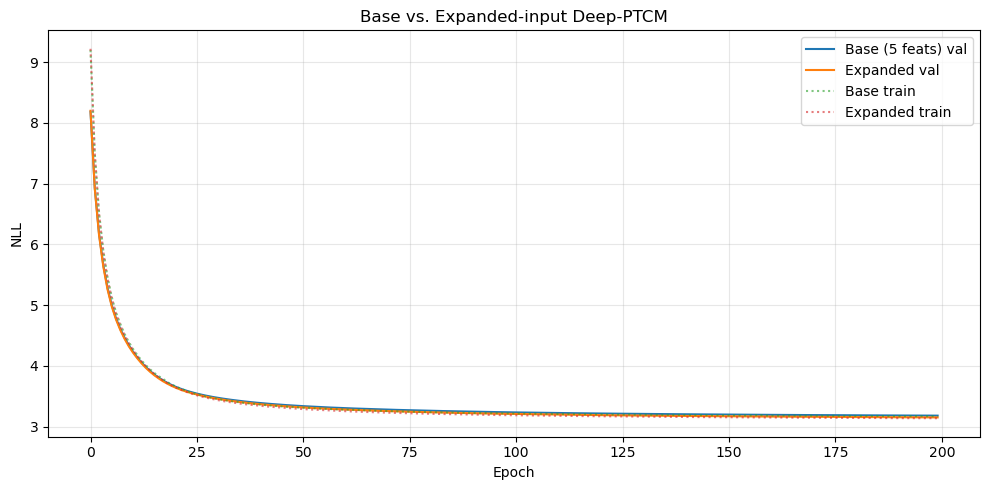

In [21]:
# Train Deep-PTCM on expanded inputs (same hyperparameters as the base model)
model_ext = fit_deep_ptcm_competing_risks(
    df=train_ext,
    feature_cols=EXPANDED_FEATURE_COLS,
    duration_col='duration',
    event_col='event_code',
    event_types=[1, 2],
    val_df=val_ext,
    **PTCM_PARAMS,
)

print(f"\nExpanded Deep-PTCM training complete.")
print(f"  Input dim:     {len(EXPANDED_FEATURE_COLS)}")
print(f"  Epochs run:    {len(model_ext.history_['train_loss'])}")
print(f"  Best val loss: {min(model_ext.history_['val_loss']):.4f}")

# Training curve overlay (base vs expanded)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(model.history_['val_loss'], label='Base (5 feats) val', linestyle='-')
ax.plot(model_ext.history_['val_loss'], label='Expanded val', linestyle='-')
ax.plot(model.history_['train_loss'], label='Base train', linestyle=':', alpha=0.6)
ax.plot(model_ext.history_['train_loss'], label='Expanded train', linestyle=':', alpha=0.6)
ax.set_xlabel('Epoch')
ax.set_ylabel('NLL')
ax.set_title('Base vs. Expanded-input Deep-PTCM')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'expanded_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Evaluate both models on the SAME (extended) test set for a fair comparison.
# Base model takes the 5 numeric features; expanded model takes numeric + one-hot.
test_durations_ext = test_ext['duration'].values
test_events_ext = test_ext['event_code'].values
X_test_base_on_ext = test_ext[NUMERIC_FEATURES]
X_test_expanded = test_ext[EXPANDED_FEATURE_COLS]

eval_rows = []
for model_obj, model_name, X_in in [
    (model, 'Deep-PTCM (base, 5 feats)', X_test_base_on_ext),
    (model_ext, 'Deep-PTCM (expanded)', X_test_expanded),
]:
    for event_code, event_name in [(1, 'Prepay'), (2, 'Default')]:
        for t in EVAL_TIMES:
            risk = model_obj.predict_risk(X_in, event=event_code, time=t)
            c_idx, _, _ = time_dependent_concordance_index(
                test_durations_ext, test_events_ext, risk, t, event_code
            )
            cif_t = model_obj.predict_cumulative_incidence(
                X_in, event=event_code, times=np.array([t])
            )[:, 0]
            bs = brier_score_competing_risks(
                test_durations_ext, test_events_ext, cif_t, t, event_code
            )
            eval_rows.append({
                'Model': model_name, 'Event': event_name,
                'Horizon': t, 'C-index': c_idx, 'Brier Score': bs,
            })

        # IBS over 1..72
        cif_at_grid = model_obj.predict_cumulative_incidence(
            X_in, event=event_code, times=ibs_grid
        )
        ibs = integrated_brier_score(
            test_durations_ext, test_events_ext,
            cif_at_grid, ibs_grid, event_of_interest=event_code,
        )
        eval_rows.append({
            'Model': model_name, 'Event': event_name,
            'Horizon': 'IBS', 'C-index': np.nan, 'Brier Score': ibs,
        })

ext_cmp = pd.DataFrame(eval_rows)

print("=== C-index (higher is better) ===")
c_piv = ext_cmp[ext_cmp['Horizon'] != 'IBS'].pivot_table(
    index=['Event', 'Horizon'], columns='Model', values='C-index'
)
c_piv['Delta'] = c_piv['Deep-PTCM (expanded)'] - c_piv['Deep-PTCM (base, 5 feats)']
print(c_piv.round(4).to_string())

print("\n=== Brier score (lower is better) ===")
bs_piv = ext_cmp[ext_cmp['Horizon'] != 'IBS'].pivot_table(
    index=['Event', 'Horizon'], columns='Model', values='Brier Score'
)
bs_piv['Delta'] = bs_piv['Deep-PTCM (expanded)'] - bs_piv['Deep-PTCM (base, 5 feats)']
print(bs_piv.round(6).to_string())

print("\n=== IBS (lower is better) ===")
ibs_piv = ext_cmp[ext_cmp['Horizon'] == 'IBS'].pivot_table(
    index='Event', columns='Model', values='Brier Score'
)
ibs_piv['Delta'] = ibs_piv['Deep-PTCM (expanded)'] - ibs_piv['Deep-PTCM (base, 5 feats)']
print(ibs_piv.round(6).to_string())

print("\n=== AUC_cure (min_followup=120) ===")
print(f"  {'Model':<32s} | {'overall':>8s} | {'prepay':>8s} | {'default':>8s}")
for model_obj, model_name, X_in in [
    (model, 'Deep-PTCM (base, 5 feats)', X_test_base_on_ext),
    (model_ext, 'Deep-PTCM (expanded)', X_test_expanded),
]:
    cure_pred = model_obj.predict_cure_fraction(X_in)
    auc_o = auc_cure(test_events_ext, test_durations_ext,
                     cure_pred['overall'], min_followup=120)
    auc_p = auc_cure(test_events_ext, test_durations_ext,
                     cure_pred['prepay'],  min_followup=120, event_of_interest=1)
    auc_d = auc_cure(test_events_ext, test_durations_ext,
                     cure_pred['default'], min_followup=120, event_of_interest=2)
    print(f"  {model_name:<32s} | {auc_o:>8.4f} | {auc_p:>8.4f} | {auc_d:>8.4f}")

# Visual comparison: C-index bar chart per event/horizon
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (ev_code, ev_name) in zip(axes, [(1, 'Prepay'), (2, 'Default')]):
    sub = ext_cmp[(ext_cmp['Event'] == ev_name) & (ext_cmp['Horizon'] != 'IBS')]
    pivot = sub.pivot_table(index='Horizon', columns='Model', values='C-index')
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'{ev_name}: C-index by horizon')
    ax.set_ylabel('C-index')
    ax.set_xlabel('Horizon (months)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'expanded_vs_base_cindex.png', dpi=150, bbox_inches='tight')
plt.show()

## Cash Flow Projection (ALM)

The Deep-PTCM is a **static** competing-risks model — $\theta_k(\mathbf{x})$ is fixed at origination — so it can produce a closed-form expected cash-flow profile for each loan. We extract discrete cause-specific hazards from the model's CIF and overall survival:

$$h_k(t) = \frac{\mathrm{CIF}_k(t) - \mathrm{CIF}_k(t-1)}{S(t-1)}$$

and feed them into the same monthly amortisation + competing-risks recursion used by `RSFCashFlowEngine` in **notebook 15**. The shared engine means PTCM- and RSF-driven cash flows are computed identically downstream of the hazard step, so any difference in the projected cash-flow profile is attributable to the hazard model rather than to engine-level conventions.

**Caveats**
- No time-varying covariates: the hazard for any future month is determined at origination and does not react to rate or HPI moves. For scenario stress (rate +200 bps, HPI -20 %, etc.) the panel-based RSF / Sadhwani / DeepHit models in notebooks 15 / 18 / 08 are still the right tools.
- We assume `orig_loan_term = 360` (consistent with the FRM30 filter on the Blumenstock dataset).
- We project from `current_loan_age = 0` so each fold-10 test loan starts from origination.

In [23]:
from src.alm.deep_ptcm_cash_flow_engine import (
    DeepPTCMCashFlowEngine,
    DeepPTCMCashFlowConfig,
)

T_PROJ = 360
LGD = 0.25

loans_df_cf = test_df[['loan_sequence_number', 'int_rate', 'orig_upb']].copy().reset_index(drop=True)
loans_df_cf['orig_loan_term'] = 360
loans_df_cf['current_loan_age'] = 0

X_cf = test_df[FEATURE_COLS].reset_index(drop=True)

engine = DeepPTCMCashFlowEngine(
    ptcm_model=model,
    prepay_event=1,
    default_event=2,
    config=DeepPTCMCashFlowConfig(
        lgd=LGD, projection_horizon=T_PROJ, batch_size=2000,
    ),
)
print(f'Cash-flow engine ready. {len(loans_df_cf):,} test loans, T={T_PROJ} months, LGD={LGD}.')

Cash-flow engine ready. 10,000 test loans, T=360 months, LGD=0.25.


In [24]:
%%time
cf_results = engine.project_cash_flows(loans_df_cf, X_cf)
portfolio_cf = engine.aggregate_portfolio(cf_results)

orig_upb_total = float(loans_df_cf['orig_upb'].sum())
print('\nPortfolio cash-flow summary (Deep-PTCM):')
print(f"  Total interest:            ${cf_results['interest'].sum():>15,.0f}")
print(f"  Total scheduled principal: ${cf_results['scheduled_principal'].sum():>15,.0f}")
print(f"  Total prepayment:          ${cf_results['prepayment'].sum():>15,.0f}")
print(f"  Total recovery:            ${cf_results['recovery'].sum():>15,.0f}")
print(f"  Total expected loss:       ${cf_results['loss'].sum():>15,.0f}")
print(f"  Aggregate cash flow:       ${cf_results['total_cf'].sum():>15,.0f}")
print(f"  Total UPB at origination:  ${orig_upb_total:>15,.0f}")
print(f"  Loss / orig UPB:           {cf_results['loss'].sum() / orig_upb_total:>15.4%}")
print(f"  Avg WAL contribution year: {(np.arange(1, T_PROJ + 1) * portfolio_cf['principal_return']).sum() / portfolio_cf['principal_return'].sum() / 12:>15.2f}")
print(f"\nFirst 12 months of portfolio cash flow:")
print(portfolio_cf.head(12).to_string(index=False))

/Users/bartbronselaer/Developer/freddie-mac-survival-analysis/src/alm/rsf_cash_flow_engine.py:266: RuntimeWarning: divide by zero encountered in divide
  cfg.max_hazard_total / h_sum,


/Users/bartbronselaer/Developer/freddie-mac-survival-analysis/src/alm/rsf_cash_flow_engine.py:266: RuntimeWarning: divide by zero encountered in divide
  cfg.max_hazard_total / h_sum,


/Users/bartbronselaer/Developer/freddie-mac-survival-analysis/src/alm/rsf_cash_flow_engine.py:266: RuntimeWarning: divide by zero encountered in divide
  cfg.max_hazard_total / h_sum,


/Users/bartbronselaer/Developer/freddie-mac-survival-analysis/src/alm/rsf_cash_flow_engine.py:266: RuntimeWarning: divide by zero encountered in divide
  cfg.max_hazard_total / h_sum,



Portfolio cash-flow summary (Deep-PTCM):
  Total interest:            $    750,387,568
  Total scheduled principal: $    605,859,398
  Total prepayment:          $  1,894,634,954
  Total recovery:            $     18,023,782
  Total expected loss:       $      6,007,927
  Aggregate cash flow:       $  3,268,905,702
  Total UPB at origination:  $  2,524,526,000
  Loss / orig UPB:                   0.2380%
  Avg WAL contribution year:            6.58

First 12 months of portfolio cash flow:
 month     interest  scheduled_principal   prepayment     recovery          loss     total_cf  avg_survival  cumulative_cf  principal_return
     1 9.753467e+06         3.320746e+06 1.951128e+07 1.560322e+06 520107.393156 3.414581e+07      0.991930   3.414581e+07      2.439234e+07
     2 9.655911e+06         3.304948e+06 1.922059e+07 1.424315e+06 474771.717197 3.360576e+07      0.984029   6.775157e+07      2.394985e+07
     3 9.560268e+06         3.289563e+06 1.893615e+07 1.300351e+06 433450.470755 3

/Users/bartbronselaer/Developer/freddie-mac-survival-analysis/src/alm/rsf_cash_flow_engine.py:266: RuntimeWarning: divide by zero encountered in divide
  cfg.max_hazard_total / h_sum,


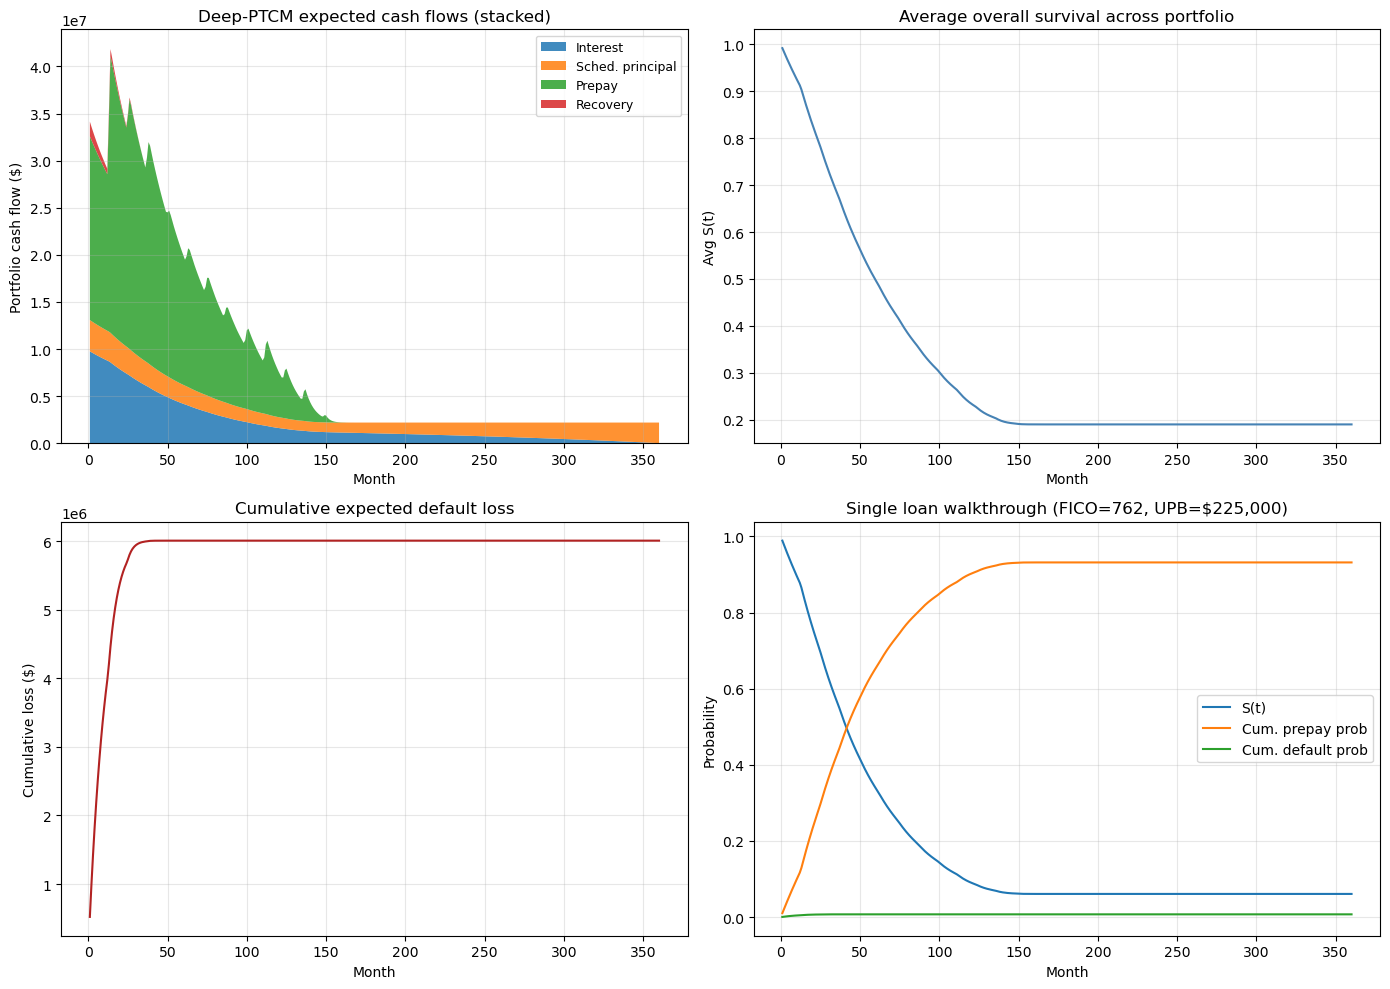

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

months = portfolio_cf['month'].values

# -- Stacked components ---
ax = axes[0, 0]
ax.stackplot(
    months,
    portfolio_cf['interest'],
    portfolio_cf['scheduled_principal'],
    portfolio_cf['prepayment'],
    portfolio_cf['recovery'],
    labels=['Interest', 'Sched. principal', 'Prepay', 'Recovery'],
    alpha=0.85,
)
ax.set_xlabel('Month')
ax.set_ylabel('Portfolio cash flow ($)')
ax.set_title('Deep-PTCM expected cash flows (stacked)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# --- Average overall survival ---
ax = axes[0, 1]
ax.plot(months, portfolio_cf['avg_survival'], color='steelblue')
ax.set_xlabel('Month')
ax.set_ylabel('Avg S(t)')
ax.set_title('Average overall survival across portfolio')
ax.grid(True, alpha=0.3)

# --- Cumulative loss ---
ax = axes[1, 0]
ax.plot(months, portfolio_cf['loss'].cumsum(), color='firebrick')
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative loss ($)')
ax.set_title('Cumulative expected default loss')
ax.grid(True, alpha=0.3)

# --- Single-loan walkthrough (median FICO loan) ---
ax = axes[1, 1]
i_demo = int(np.argsort(test_df['fico_score'].values)[len(test_df) // 2])
ax.plot(months, cf_results['survival'][i_demo], label='S(t)')
ax.plot(months, np.cumsum(cf_results['f_prepay'][i_demo]), label='Cum. prepay prob')
ax.plot(months, np.cumsum(cf_results['f_default'][i_demo]), label='Cum. default prob')
fico_demo = test_df['fico_score'].iloc[i_demo]
upb_demo = test_df['orig_upb'].iloc[i_demo]
ax.set_xlabel('Month')
ax.set_ylabel('Probability')
ax.set_title(f'Single loan walkthrough (FICO={fico_demo:.0f}, UPB=${upb_demo:,.0f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cash_flow_projection.png', dpi=150, bbox_inches='tight')
plt.show()

### Optional overlay: PTCM vs RSF on the same loans

The cell below tries to load the RSF models saved by **notebook 07** and run the panel-based RSF cash-flow engine on the same fold-10 loans, using the panel-style feature columns the RSF was trained on (`STATIC + BEHAVIORAL + MACRO`, evaluated at the per-loan terminal observation in `blumenstock_dataset2`). The PTCM uses only the 5 origination features.

**Read carefully**: this is *not* a perfectly fair comparison because RSF was trained on time-varying snapshots and we are evaluating it at the loan's *last observed* snapshot, while PTCM is genuinely projecting from origination. The overlay tells you whether the two model classes agree on the broad shape of expected cash flows for the same population — not which one is "right" at any given month.

In [26]:
# Optional: overlay the same projection from notebook 07's RSF models.
import pickle

try:
    with open(MODELS_DIR / 'rsf_prepay.pkl', 'rb') as f:
        rsf_prepay = pickle.load(f)
    with open(MODELS_DIR / 'rsf_default.pkl', 'rb') as f:
        rsf_default = pickle.load(f)

    from src.alm.rsf_cash_flow_engine import RSFCashFlowEngine, RSFCashFlowConfig
    from src.competing_risks.sadhwani_net import ALL_FEATURES as RSF_FEATURES

    # Recreate RSF inputs from the loan-level Blumenstock frame.
    # bal_repaid_lag1 is approximated by bal_repaid (loan-level final value).
    rsf_input = test_df.copy()
    if 'bal_repaid_lag1' not in rsf_input.columns and 'bal_repaid' in rsf_input.columns:
        rsf_input['bal_repaid_lag1'] = rsf_input['bal_repaid']
    missing = [c for c in RSF_FEATURES if c not in rsf_input.columns]
    if missing:
        raise RuntimeError(f'RSF features missing from test_df: {missing}')

    X_rsf = rsf_input[RSF_FEATURES].astype(float).values
    rsf_engine = RSFCashFlowEngine(
        rsf_prepay, rsf_default,
        config=RSFCashFlowConfig(lgd=LGD, projection_horizon=T_PROJ, batch_size=2000),
    )
    rsf_cf = rsf_engine.project_cash_flows(loans_df_cf, X_rsf)
    rsf_portfolio = rsf_engine.aggregate_portfolio(rsf_cf)

    # Plot overlays
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.plot(months, portfolio_cf['total_cf'], label='Deep-PTCM', color='steelblue')
    ax.plot(months, rsf_portfolio['total_cf'], label='RSF', color='firebrick', linestyle='--')
    ax.set_title('Total expected cash flow')
    ax.set_xlabel('Month'); ax.set_ylabel('$')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(months, portfolio_cf['avg_survival'], label='Deep-PTCM', color='steelblue')
    ax.plot(months, rsf_portfolio['avg_survival'], label='RSF', color='firebrick', linestyle='--')
    ax.set_title('Average overall survival S(t)')
    ax.set_xlabel('Month'); ax.set_ylabel('S(t)')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.plot(months, portfolio_cf['prepayment'], label='Deep-PTCM', color='steelblue')
    ax.plot(months, rsf_portfolio['prepayment'], label='RSF', color='firebrick', linestyle='--')
    ax.set_title('Expected prepayment cash flow')
    ax.set_xlabel('Month'); ax.set_ylabel('$')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.plot(months, portfolio_cf['loss'].cumsum(), label='Deep-PTCM', color='steelblue')
    ax.plot(months, rsf_portfolio['loss'].cumsum(), label='RSF', color='firebrick', linestyle='--')
    ax.set_title('Cumulative expected default loss')
    ax.set_xlabel('Month'); ax.set_ylabel('$')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'cash_flow_ptcm_vs_rsf.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('--- Aggregate deltas (PTCM minus RSF) ---')
    print(f"  Total CF:       ${cf_results['total_cf'].sum() - rsf_cf['total_cf'].sum():>15,.0f}")
    print(f"  Total prepay:   ${cf_results['prepayment'].sum() - rsf_cf['prepayment'].sum():>15,.0f}")
    print(f"  Total loss:     ${cf_results['loss'].sum() - rsf_cf['loss'].sum():>15,.0f}")
    print(f"  Total interest: ${cf_results['interest'].sum() - rsf_cf['interest'].sum():>15,.0f}")
except FileNotFoundError as e:
    print(f'RSF models not found at {MODELS_DIR}/rsf_*.pkl. Run notebook 07 first to save them.')
    print(f'(Original error: {e})')
except Exception as e:
    print(f'RSF overlay skipped: {type(e).__name__}: {e}')

RSF overlay skipped: ValueError: X has 13 features, but RandomSurvivalForest is expecting 21 features as input.


## Save Models

In [27]:
# Save both models
model.save(str(MODELS_DIR / 'deep_ptcm.pt'))
model_ort.save(str(MODELS_DIR / 'deep_ptcm_ort.pt'))
print(f"Saved models to {MODELS_DIR}")

# Verify round-trip
model_loaded = CompetingRisksDeepPTCM.load(str(MODELS_DIR / 'deep_ptcm.pt'))
risk_orig = model.predict_risk(X_test, event=1, time=72)
risk_loaded = model_loaded.predict_risk(X_test, event=1, time=72)
print(f"Load verification - max difference: {np.abs(risk_orig - risk_loaded).max():.1e}")

Saved models to ../models
Load verification - max difference: 0.0e+00


## Summary

### Deep-PTCM Results

| Metric | Description |
|--------|-------------|
| **C-index** | Time-dependent concordance at t = 24, 48, 72 months |
| **Brier Score** | Calibration at each horizon |
| **IBS** | Integrated Brier Score over t = 1..72 |
| **AUC_cure** | Discrimination between cured and uncured borrowers |

### Key Findings

- The Deep-PTCM provides **cure fractions** for each competing risk, which other models cannot
- The **orthogonalized variant** yields interpretable linear coefficients while maintaining DNN flexibility
- Cure fractions for default should be high (most borrowers never default), while prepayment cure fractions capture the subset of borrowers who hold their mortgage to maturity

### Comparison with Other Models

The C-index results can be directly compared with:
- **Cause-Specific Cox** (notebook 05)
- **DeepHit** (notebook 08)
- **Random Survival Forest** (notebook 07)
- **Sadhwani NN** (notebook 18)

Note: Those models use time-varying panel data, while Deep-PTCM uses static loan-level features only. The comparison reveals the relative value of temporal vs. cure-model structure.

In [ ]:
# Final summary table
print("=" * 70)
print("DEEP-PTCM COMPETING RISKS - FINAL RESULTS")
print("=" * 70)
print(f"\nDataset: blumenstock_dataset2.parquet")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Features: {FEATURE_COLS}")
print(f"\n{results_df.to_string(index=False)}")
print(f"\nAUC_cure (min_followup=120):")
print(f"  overall: {auc_overall:.4f}")
print(f"  prepay : {auc_prepay :.4f}")
print(f"  default: {auc_default:.4f}")
print("=" * 70)